# Notebook - DOGIS Inversion Sampler

In [2]:
import torch
from models.backbone import backbone_unet
import matplotlib.pyplot as plt
from models.FNO import FNO2d
import numpy as np
import random
from models.FM import FlowMatching
from functions.data import FM_dataloader
device = [i for i in range(torch.cuda.device_count())]
device = device[0]

In [13]:
SEED = 128
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### Define Scenario here ↓

In [14]:
data_type = "SHM"
obs_num = 16
hyper_params = {"Darcyflow": {"time":0.95,"tensity":0.7},"SHM": {"time":0.95,"tensity":1.2}} 

### Load Models

In [15]:
path = f"{project_root}/output/{data_type}-FMInverse-op1.0-16/checkpoints/best.pt"
checkpoint = torch.load(path, weights_only=False)
size_params = checkpoint["size_params"]
backbone = backbone_unet(
            input_channels = size_params["field_channels"],
            field_size = size_params["field_size"],
            spatial_feat_channels = size_params["obs_channel"],
            global_feat_size = size_params["global_feat_size"],
            num_res_blocks = checkpoint["num_res_blocks"],  # num of res block for each step
            attention_resolutions = checkpoint["attention_resolutions"],  # Attn insertion at: 32x32
            dropout = checkpoint["dropout"],
            channel_mult = checkpoint["channel_mult"],  # channel multipliers
            num_heads = checkpoint["num_heads"],  # num of heads,
            obs_num = 16,)

backbone = backbone.cuda(device)
model = FlowMatching(model = backbone)
model = model.cuda(device)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [16]:
path = f"{project_root}/output/{data_type}-FNOForward/checkpoints/best.pt"
checkpoint = torch.load(path)
size_params = checkpoint["size_params"]
fno_model = FNO2d(
        field_channels=size_params["field_channels"],
        obs_channels=size_params["obs_channels"],
        modes1=checkpoint["fno_modes"],
        modes2=checkpoint["fno_modes"],
        width=checkpoint["fno_width"],
        )
fno_model = fno_model.cuda(device)
fno_model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [17]:
cmap_dict = {
    "SHM":"Greys_r",
    "Darcyflow":"jet",}

### Load Dataset

In [18]:
test_loader, data_params = FM_dataloader(
                data_dir = f"{project_root}/data/{data_type}/testset.h5",
                shuffle = False,
                num_sensor_points = obs_num,
                batch_size = 10,
                num_workers = 4,
            )

Dataset Loaded. Sobolev Gradients & Random 16-Point Masking Enabled.


In [19]:
for inputs in test_loader:
    target_field = inputs["target"].to(device)
    mask = inputs["mask"].to(device)
    spatial_feat = inputs["spatial_feat"].to(device)
    global_feat = inputs["global_feat"].to(device)
    break

print(f"input_field: {target_field.shape}")
print(f"mask: {mask.shape}")
print(f"spatial_feat: {spatial_feat.shape}")
print(f"global_feat: {global_feat.shape}")

input_field: torch.Size([10, 1, 64, 64])
mask: torch.Size([10, 64, 64])
spatial_feat: torch.Size([10, 5, 64, 64])
global_feat: torch.Size([10, 80])


### Field Generations

In [20]:
field_pred_fno = model.FNO_sampler(target_field.shape, steps=50, device=device, 
               spatial_feat=spatial_feat, global_feat=global_feat, 
               cfg_scale=1.0,
               use_physics_guidance=True,
               fno_model=fno_model,  
               y_obs_sparse=spatial_feat,  
               mask=mask, 
               guidance_scale=hyper_params[data_type]["tensity"], 
               guidance_start_t=hyper_params[data_type]["time"]) 

print(hyper_params[data_type]["tensity"])
field_pred_fno = field_pred_fno.detach().cpu().numpy().squeeze()
display(field_pred_fno.shape)

1.2


(10, 64, 64)

In [21]:
field_pred = model.sample(target_field.shape, spatial_feat.shape, 50, device, spatial_feat, global_feat)
field_pred = field_pred.detach().cpu().numpy().squeeze()
display(field_pred.shape)

(10, 64, 64)

### Visualizations

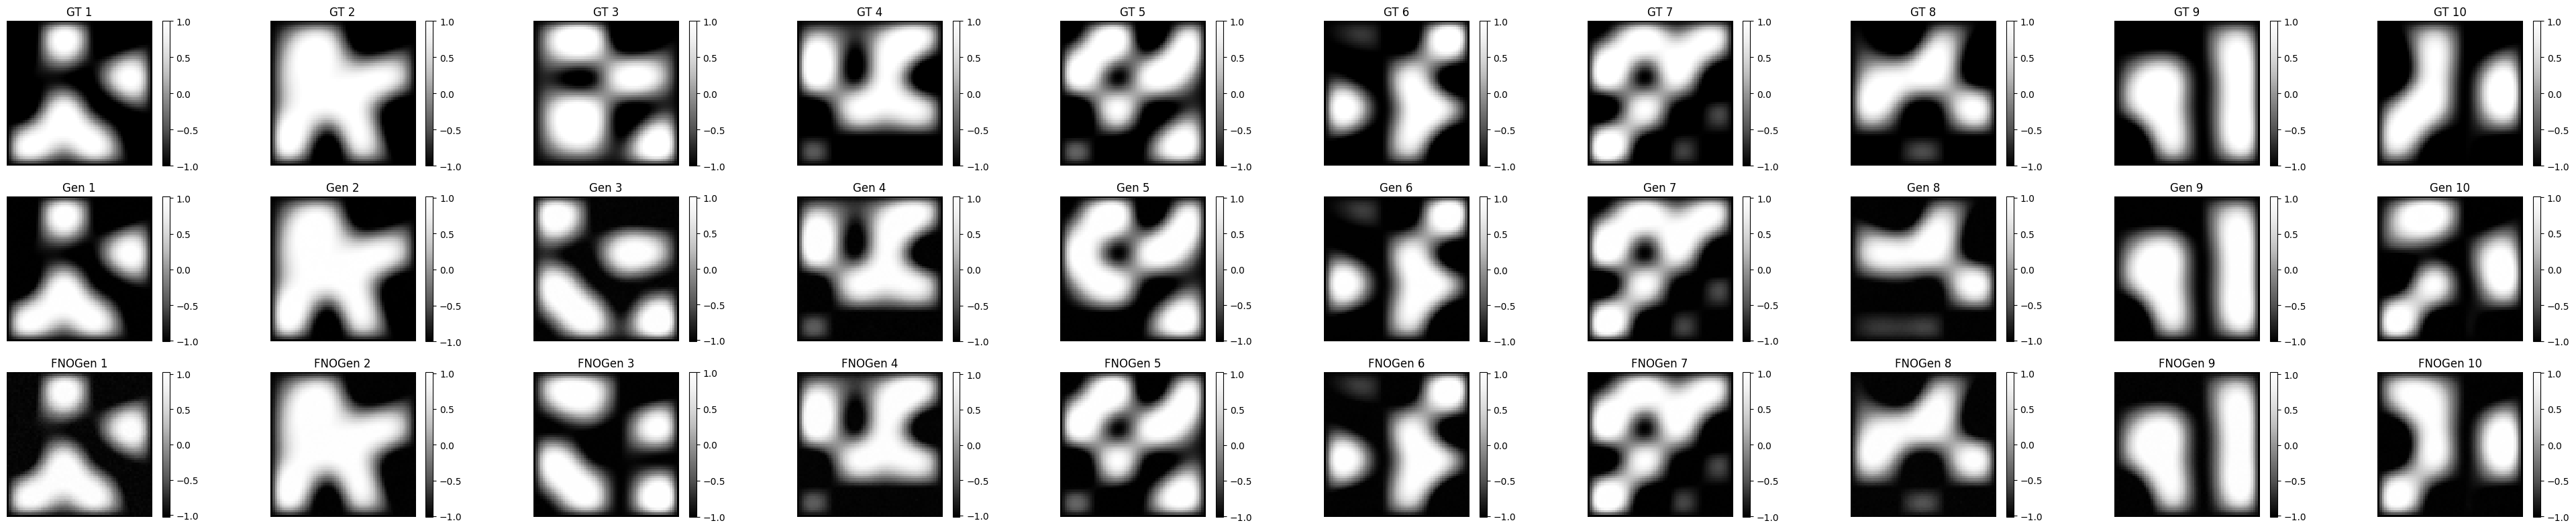

In [22]:
fig, axes = plt.subplots(3, 10, figsize=(8*5, 8))  # 2行3列

# 假设 predict_num = 4, 2行2列
for row_idx in range(3):
    for col_idx in range(10):
        if row_idx == 0:
            ax_input = axes[row_idx, col_idx].imshow(target_field[col_idx][0].detach().cpu().numpy(), cmap=cmap_dict[data_type])
            axes[row_idx, col_idx].axis('off')
            axes[row_idx, col_idx].set_title(f'GT {col_idx+1}', fontsize=12)
            plt.colorbar(ax_input, ax=axes[row_idx, col_idx], fraction=0.046, pad=0.04)

        if row_idx == 1:
            ax_input = axes[row_idx, col_idx].imshow(field_pred[col_idx], cmap=cmap_dict[data_type])
            axes[row_idx, col_idx].axis('off')
            axes[row_idx, col_idx].set_title(f'Gen {col_idx+1}', fontsize=12)
            plt.colorbar(ax_input, ax=axes[row_idx, col_idx], fraction=0.046, pad=0.04)   

        if row_idx == 2:
            ax_input = axes[row_idx, col_idx].imshow(field_pred_fno[col_idx], cmap=cmap_dict[data_type])
            axes[row_idx, col_idx].axis('off')
            axes[row_idx, col_idx].set_title(f'FNOGen {col_idx+1}', fontsize=12)
            plt.colorbar(ax_input, ax=axes[row_idx, col_idx], fraction=0.046, pad=0.04) 
            
plt.tight_layout()